In [5]:
# Core libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Text processing
import re
import string
import nltk
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from nltk.stem import PorterStemmer

# Machine Learning (Scikit-learn)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

# Metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [6]:
df = pd.read_csv("/Users/avomine/VSCode/ML/Third_Eye/Datasets/df.csv")  # adjust filename

df.tail()

,label,text
365443,0,on escapenumber escapenumber escapenumber rob ...
365444,2,we have everything you need escapelong cialesc...
365445,0,hi quick question say i have a date variable i...
365446,2,thank you for your loan request which we recie...
365447,0,this is an automatically generated delivery st...


In [7]:
# Drop duplicates
df.drop_duplicates(inplace=True)

# Drop nulls
df.dropna(inplace=True)

# Check target column
df['label'].value_counts()

label
0    128206
2    109905
1     42845
Name: count, dtype: int64

In [8]:
label_map = {
    0: 'ham',
    1: 'phish',
    2: 'spam'
}

df['label'] = df['label'].map(label_map)

In [9]:
df['label'].value_counts()

label
ham      128206
spam     109905
phish     42845
Name: count, dtype: int64

### Text Cleaning Function

In [10]:
import re
import string
import nltk

stop_words = set(ENGLISH_STOP_WORDS)
stemmer = PorterStemmer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    
    words = [stemmer.stem(word) for word in words if word not in stop_words]
    
    return " ".join(words)

df['clean_text'] = df['text'].apply(clean_text)

In [11]:
df['label'].value_counts()

label
ham      128206
spam     109905
phish     42845
Name: count, dtype: int64

### EDA

In [12]:
df['length'] = df['text'].apply(len)

# Remove extreme outliers
df = df[df['length'] < 10000]

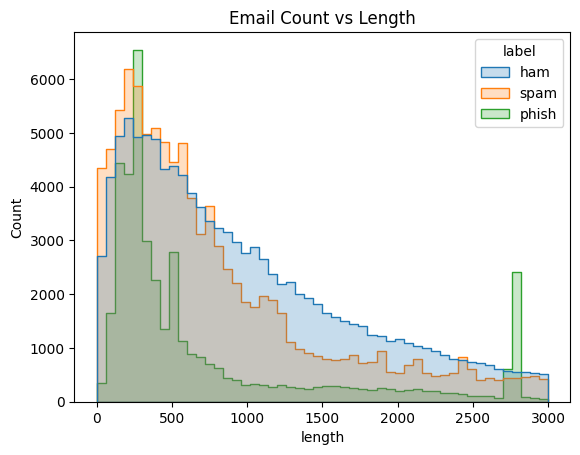

In [13]:
df_filtered = df[df['length'] < 3000]

sns.histplot(
    data=df_filtered,
    x='length',
    hue='label',
    bins=50,
    element='step'
)

plt.title("Email Count vs Length")
plt.show()

### tTHe thick circles are outliers

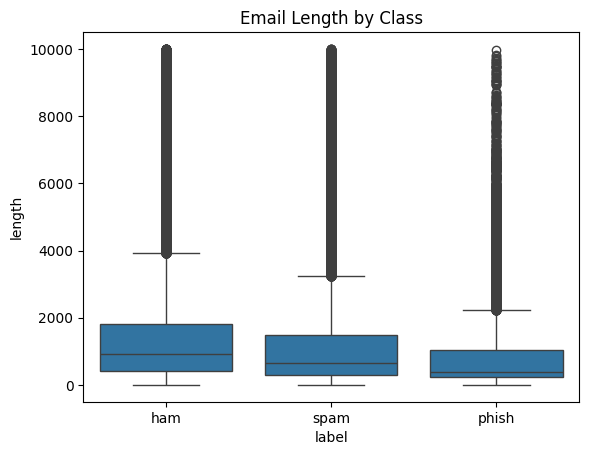

In [14]:
sns.boxplot(x='label', y='length', data=df)
plt.title("Email Length by Class")
plt.show()

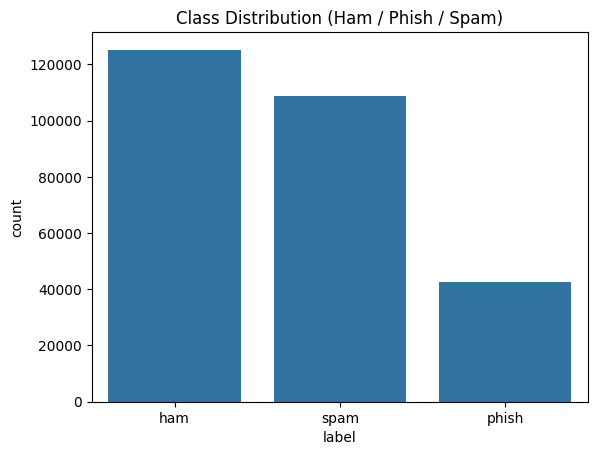

In [15]:
sns.countplot(x='label', data=df)
plt.title("Class Distribution (Ham / Phish / Spam)")
plt.show()

### Top Words Per Class

In [16]:
from collections import Counter

for label in df['label'].unique():
    words = " ".join(df[df['label'] == label]['clean_text']).split()
    common = Counter(words).most_common(10)
    
    print(f"\nTop words in {label}:")
    print(common)


Top words in ham:
[('escapenumb', 1871764), ('com', 142770), ('enron', 133237), ('messag', 96668), ('subject', 90876), ('http', 88376), ('use', 73820), ('sent', 72157), ('mail', 69529), ('e', 68814)]

Top words in spam:
[('escapenumb', 1089269), ('escapelong', 241330), ('b', 103200), ('com', 101316), ('http', 90080), ('bescapenumb', 74202), ('cescapenumb', 70474), ('compani', 67534), ('e', 58273), ('price', 51388)]

Top words in phish:
[('aug', 27884), ('email', 25875), ('compani', 21031), ('account', 17677), ('money', 16204), ('news', 15771), ('time', 15058), ('receiv', 14820), ('cnncom', 14533), ('inform', 14372)]


### Logistic Reg

In [17]:
vectorizer = TfidfVectorizer(max_features=2000)

X = vectorizer.fit_transform(df['clean_text'])  # NO toarray
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

lr = LogisticRegression(
    max_iter=200,
    solver='saga',
    n_jobs=-1
)

lr.fit(X_train, y_train)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Naive Bayes

In [18]:
nb = MultinomialNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

### Linear SVC

In [19]:
svm = LinearSVC()
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

### Eval func

In [20]:
def evaluate_model(y_test, y_pred, name):
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{name} Confusion Matrix")
    plt.show()

### Eval all models

In [21]:
print("NB:", accuracy_score(y_test, y_pred_nb))
print("SVM:", accuracy_score(y_test, y_pred_svm))
print("LR:", accuracy_score(y_test, lr.predict(X_test)))

NB: 0.8690678425561138
SVM: 0.9231214081758051
LR: 0.9262659486030289


### Test

In [22]:
def predict_email(text):
    cleaned = clean_text(text)
    vector = vectorizer.transform([cleaned])
    prediction = lr.predict(vector)
    
    return prediction[0]

# Test
print(predict_email("URGENT! Your account has been compromised, click here"))
print(predict_email("Meeting scheduled for tomorrow at 10 AM"))
print(predict_email("Win a free iPhone now!!!"))


phish
ham
spam


### Exporting toPickleFiles

In [30]:
import os
import joblib

SAVE_DIR = "/Users/avomine/VSCode/ML/Third_Eye/toPickleFiles/email_models"
os.makedirs(SAVE_DIR, exist_ok=True)

# ------------------------
# SAFETY CHECK
# ------------------------
required_vars = ["lr", "nb", "svm", "vectorizer"]

for var in required_vars:
    if var not in globals():
        raise ValueError(f"{var} is not defined. Run training cells first.")

# ------------------------
# Save individual models
# ------------------------

joblib.dump(lr, os.path.join(SAVE_DIR, "lr_model_email.pkl"))
joblib.dump(nb, os.path.join(SAVE_DIR, "nb_model_email.pkl"))
joblib.dump(svm, os.path.join(SAVE_DIR, "svm_model_email.pkl"))

# Vectorizer
joblib.dump(vectorizer, os.path.join(SAVE_DIR, "vectorizer_email.pkl"))

# Cleaner
joblib.dump(clean_text, os.path.join(SAVE_DIR, "clean_text_email.pkl"))

# ------------------------
# Save bundle (BEST)
# ------------------------

bundle = {
    "lr": lr,
    "nb": nb,
    "svm": svm,
    "vectorizer": vectorizer,
    "clean_text": clean_text
}

joblib.dump(bundle, os.path.join(SAVE_DIR, "email_model_bundle.pkl"))

print("✅ Email model exported successfully")

✅ Email model exported successfully
